In [ ]:
from google.colab import drive
import os
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
from scipy.integrate import quad
from scipy import integrate as intg
import sympy as sp
from scipy import stats
from scipy.interpolate import UnivariateSpline
import pandas as pd
from scipy.stats import linregress
from scipy.stats import norm
import os
import seaborn as sns
from matplotlib import pyplot as plt, patches
import scipy
rng = np.random.default_rng()

from scipy.interpolate import CubicSpline

from scipy.fft import fft, ifft
#!pip install ipython-autotime
%load_ext autotime

time: 478 µs (started: 2026-04-14 21:54:20 +00:00)


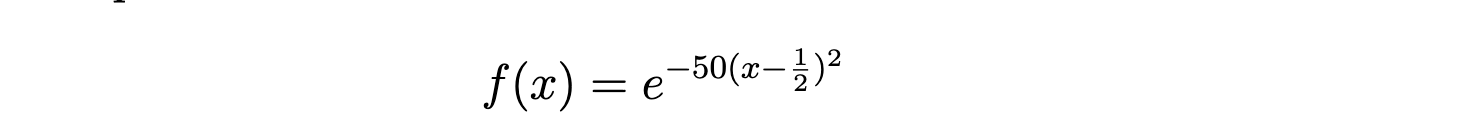

In [ ]:
color1,color2,color3,color4 = '#D76A03','#4169E1','#a52422','#8EA604'


#Equation 1
def func1(x):
  y=np.e**(-50*(x-.5)**2)
  return y


#The eq labeled (3) in our problem gives the DFT function which we have as func1b3 ...
#func1b4 ccoresponds to IDFT from eq (4) in the problem
def func1b3(x1):

  N=len(x1)
  #N=(len(X))
  n=np.arange(N)
  k=n.reshape((N,1))

  #X = np.dot(e, x) #dot product of two varriables meks it a lot easier, helpful guide at [1]
  return np.dot(np.exp(-2j * np.pi * k * n / N),x1)




#NOW FOR THE inverse DFT or equation (4) in the hw doc
def func1b4(x2):
  N=len(x2)
  n=np.arange(N)
  k=n.reshape((N,1))
  e=np.exp(2j*np.pi*k*n/N)
  #X = np.dot(e, x2)
  return (1/N) * np.dot(np.exp(2j*np.pi*k*n/N),x2)#dot product again [1]





#
##had lots of problems with the dft eqs, but this site helped a lot.
#[https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/chapter24.02-Discrete-Fourier-Transform.html]

time: 900 µs (started: 2026-04-14 21:54:24 +00:00)


In [ ]:
#print (Q1BNumerical)
## applying the function from the eq, e**(-50*(x-.5)**2) over the sample of 150,300, and 400 like the arrays in the above cell^


#assemble the sum range, ill just do 3 forr now, maybe a bigger range int he future but I just wanna make sure it works forst
c = np.linspace(0, 1, 150)
arraytest300 = np.linspace(0, 1, 300)
arraytest400 = np.linspace(0, 1, 400)

#I think this only works for the first func, not the inverse, keeping these just in case I need to change it back.

Q1BNumerical_150 = func1b3(func1(arraytest150))
Q1BNumerical_300 = func1b3(func1(arraytest300))
Q1BNumerical_400 = func1b3(func1(arraytest400))
#print (Q1BNumerical)


Q1BNumerical1A = func1b4(Q1BNumerical_150)
Q1BNumerical1B = func1b4(Q1BNumerical_300)
Q1BNumerical1C = func1b4(Q1BNumerical_400)

#print (Q1BNumerical1C)


#print (func1(arraytest))


time: 45.2 ms (started: 2026-04-14 21:54:26 +00:00)


/tmp/ipykernel_4179/3176663365.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc='upper left', fontsize=20)


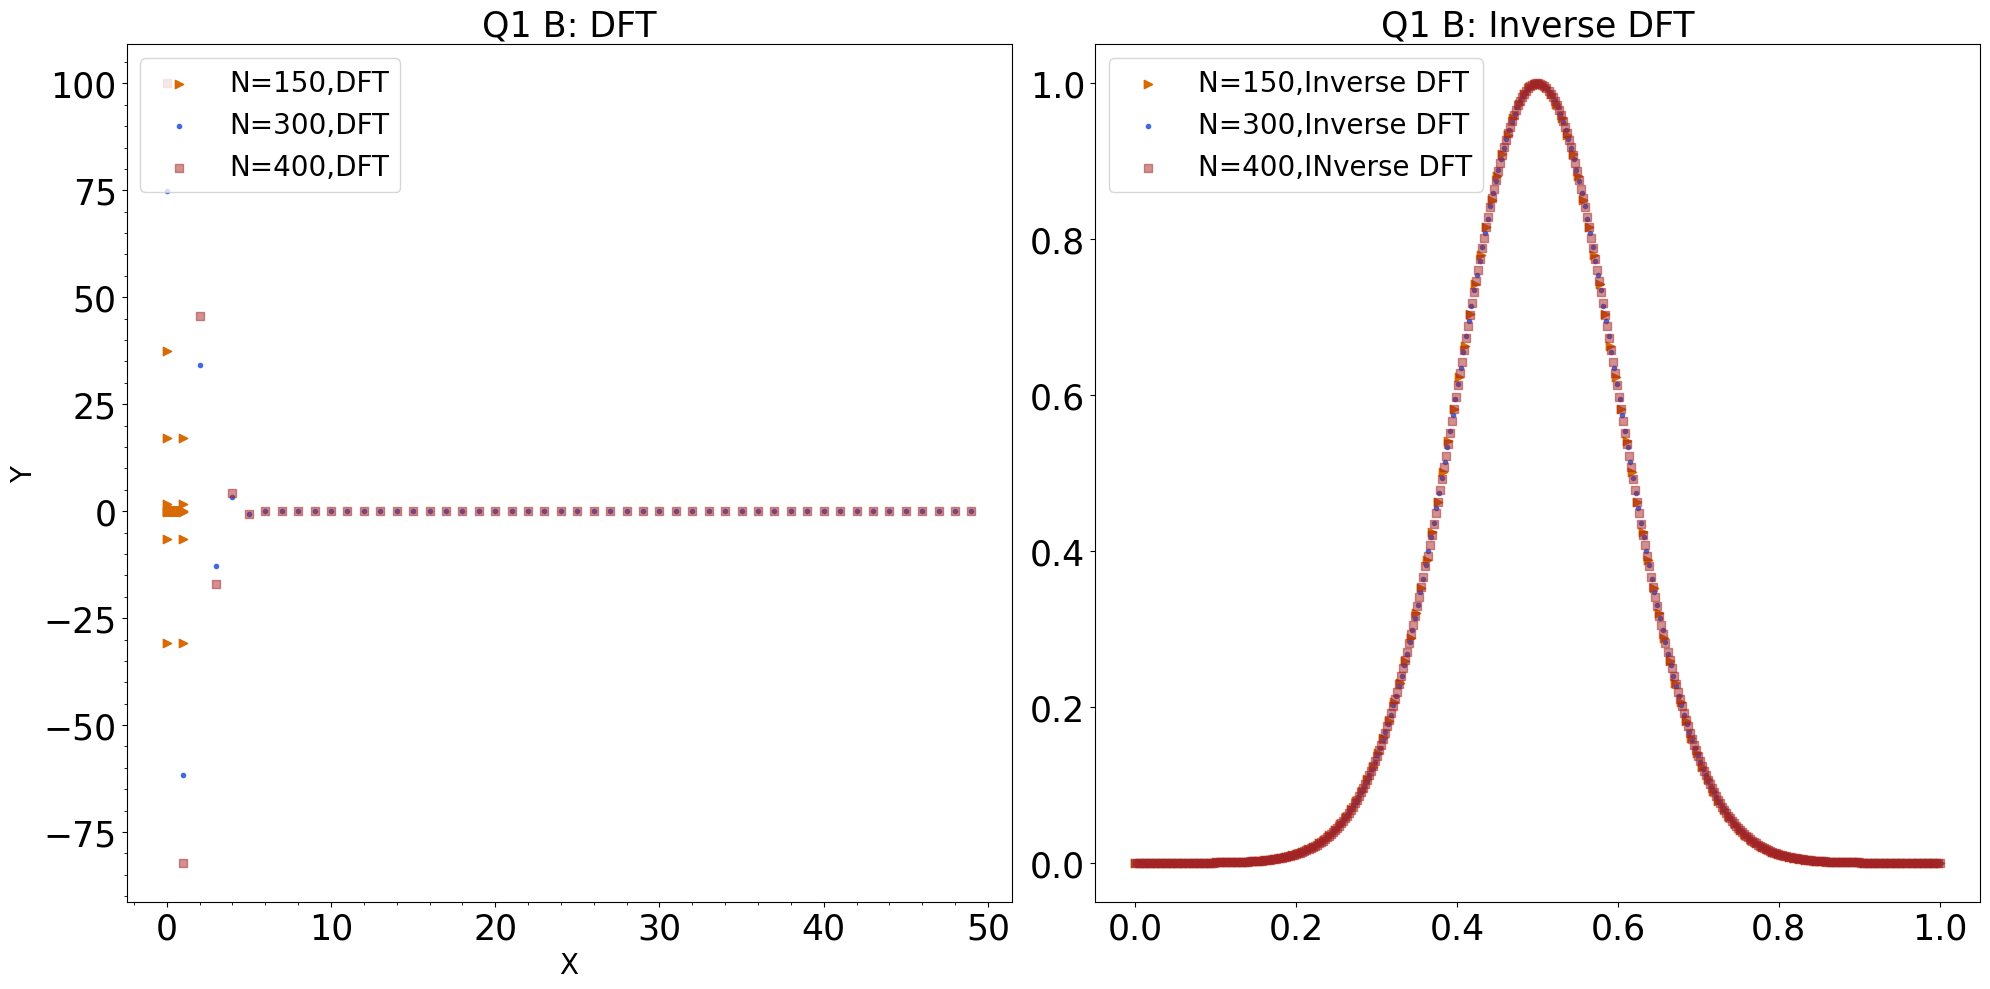

time: 722 ms (started: 2026-04-14 22:01:20 +00:00)


In [ ]:
#plotting q1 B
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))


#ax1.plot(x_rk1, y_rk1, color='#a52422', linestyle='dotted', linewidth=12, label='RK4, 50 steps')



ax1.set_xlabel("X", fontsize=20)
ax1.set_ylabel("Y", fontsize=20)
ax1.tick_params(axis='both', which='major', labelsize=25)
ax1.legend(loc='upper left', fontsize=20)
ax1.minorticks_on()
#decrease the amount plotted just so there isn't so many overlapping values... 400 was maybe too large of an N
ax1.scatter(arraytest150, (Q1BNumerical_150), label="N=150,DFT", c=color1, marker='>')
ax1.scatter(np.arange(50), (Q1BNumerical_300[:50]), label="N=300,DFT", c=color2, marker='.')
ax1.scatter(np.arange(50), (Q1BNumerical_400[:50]), label="N=400,DFT", c=color3, marker='s', alpha=.5)

#plt.savefig('Fig1',dpi = 300
ax2.scatter(arraytest150, np.real(Q1BNumerical1A), label="N=150,Inverse DFT", c=color1, marker='>')
ax2.scatter(arraytest300, np.real(Q1BNumerical1B), label="N=300,Inverse DFT", c=color2, marker='.')
ax2.scatter(arraytest400, np.real(Q1BNumerical1C), label="N=400,INverse DFT", c=color3, marker='s', alpha=.5)
ax1.legend(loc='upper left', fontsize=20)
ax2.legend(loc='upper left', fontsize=20)


ax1.set_title("Q1 B: DFT", fontsize=25)
ax2.set_title("Q1 B: Inverse DFT", fontsize=25)
ax2.tick_params(axis='both', which='major', labelsize=25)



#plt.savefig('Fig1',dpi = 300)
plt.tight_layout()
plt.show()

plt.show()

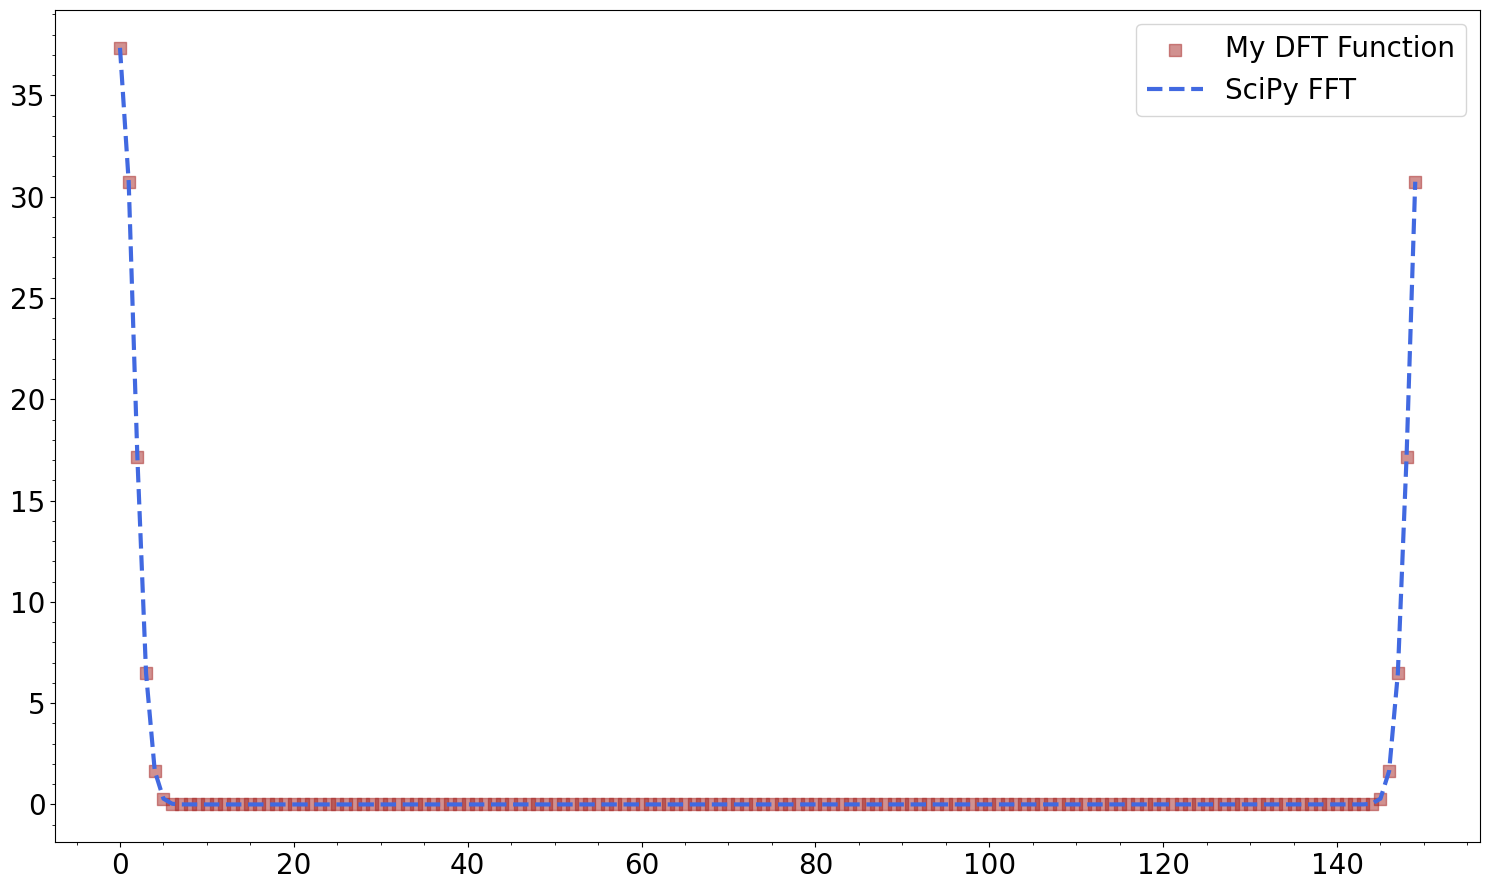

time: 263 ms (started: 2026-04-15 01:38:16 +00:00)


In [ ]:
#Plotting Q 1 C

Q1Cscipy = np.fft.fft(func1(arraytest150))



fig, (ax1) = plt.subplots(1, 1, figsize=(15, 9))

#ax1.plot(x_ex1, y_ex1, 'k-', linewidth=6, label='y = tan(x)')
#ax1.plot(x_e1, y_e1, color=color4, linestyle='--', linewidth=6, label='Euler, 50 steps')
#ax1.plot(x_rk1, y_ex1,linewidth=2, label='RK4')
ax1.scatter(np.arange(150), np.abs(Q1BNumerical_150), label="My DFT Function", c=color3, marker='s', alpha=0.5, s=80)

# plot scipy FFT
ax1.plot(np.arange(150), np.abs(Q1Cscipy), label="SciPy FFT", color=color2, linewidth=3, linestyle='dashed')


ax1.tick_params(axis='both', which='major', labelsize=20)
ax1.legend(loc='upper right', fontsize=20)
ax1.minorticks_on()

plt.tight_layout()
plt.show()

In [ ]:
-5#Question 1C:


##Q  1 C Timing, need to do all the first steps in a different cell so that way we are only getting the time output from running the FT, not any other data processes.
f_vals = func1(arraytest400)




#Baisically jsut need the scipy docc to figure it out
#  [2] https://docs.scipy.org/doc/scipy/tutorial/fft.html


time: 542 µs (started: 2026-04-14 23:42:35 +00:00)


time: 662 ms (started: 2026-04-14 23:42:35 +00:00)


In [ ]:
#Our way
Q1BNumerical_400 = func1b3(f_vals)

time: 9.57 ms (started: 2026-04-14 23:42:36 +00:00)


In [ ]:
#off the shelf fft:
Q1CTEST = np.fft.fft(func1(arraytest400))


time: 504 µs (started: 2026-04-14 23:42:38 +00:00)


In [ ]:

print("First attempt with DFT took:", "8.83 ms")
print("First attempt with FFT took:", " 727 µs")

First attempt with DFT took: 8.83 ms
First attempt with FFT took:  727 µs
time: 693 µs (started: 2026-04-14 23:42:40 +00:00)


In [ ]:
#simple timing is not enough, need to store the time as a variasble somehow... Come back to this later



time: 255 µs (started: 2026-04-14 23:42:50 +00:00)


QUESTION 2

In [ ]:

#Bringing everything over from Integration HW earrlier
def EulerTest(x0, y0, xn, n):
    h = (xn - x0) / n
    ARRR1, BRRR1 = [x0], [y0]

    # Simple Euler step
    for i in range(n):
        y0 += h * prob1func(x0, y0)
        x0 += h
        ARRR1.append(x0)
        BRRR1.append(y0.copy())

    return ARRR1, BRRR1
def RKtest(x0, y0, xn, n,function):
    h = (xn - x0) / n
    ARRR1, BRRR1 = [x0], [y0]

    for i in range(n):
        k1 = h * function(x0, y0)
        k2 = h * function(x0 + h/2, y0 + k1/2)
        k3 = h * function(x0 + h/2, y0 + k2/2)
        k4 = h * function(x0 + h, y0 + k3)

        k = (k1 + 2*k2 + 2*k3 + k4) / 6
        y0 = y0 + k
        x0 = x0 + h

        ARRR1.append(x0)
        BRRR1.append(y0.copy())

    return ARRR1, BRRR1



time: 1.01 ms (started: 2026-04-14 22:39:31 +00:00)


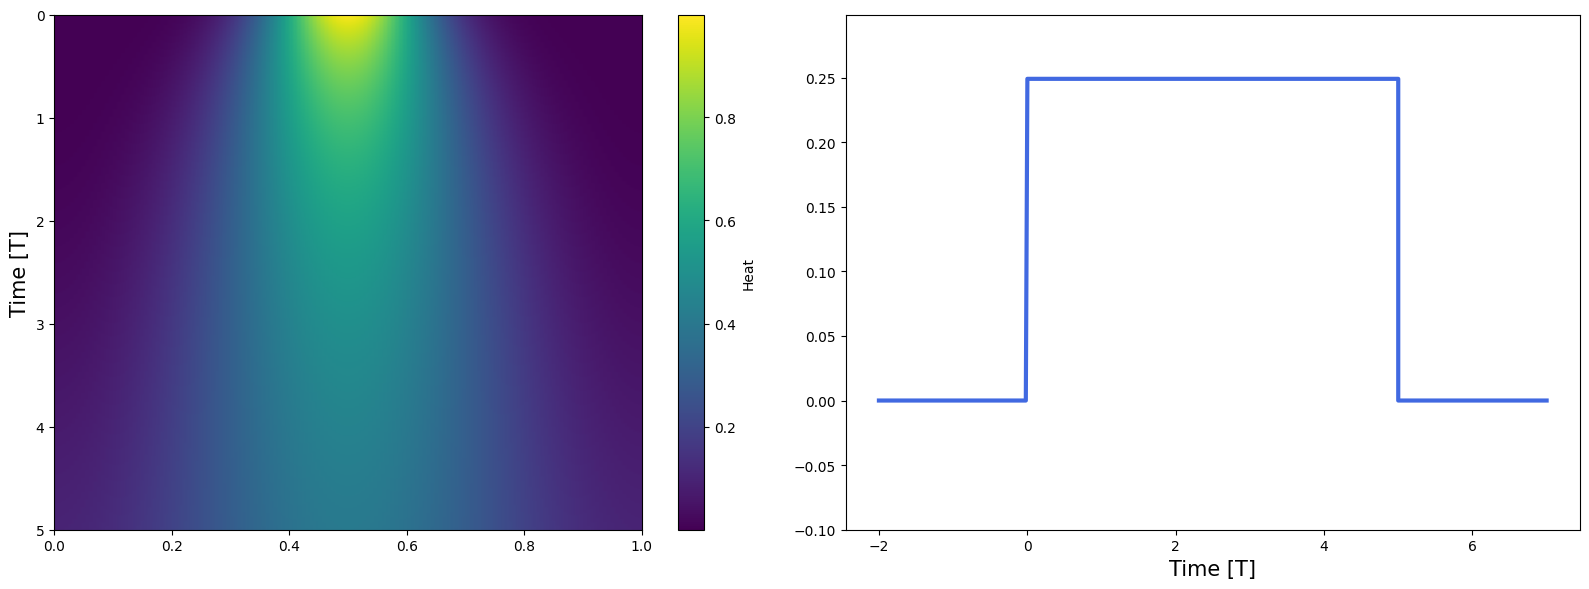

time: 12.8 s (started: 2026-04-15 00:06:32 +00:00)


In [ ]:
##QUestion 2 A
def prob2func(t, u_k):
    return -alpha_a * (k_phys**2) * u_k

alpha_a = 0.005
Timestep = 0.001
T = 5
Nt_a = int(T / Timestep)

N = 150
wavenumbers = np.fft.fftfreq(N, d=1/N) * 2 * np.pi
u0_k = func1b3(func1(arraytest150))

# RK4 test
ARRR1, BRRR1 = RKtest(0, u0_k, T, Nt_a, prob2func)

TestOut = np.zeros((Nt_a, N))
heat = []

for i in range(Nt_a):
    TestOut[i] = np.real(func1b4(BRRR1[i]))
    heat.append(np.sum(TestOut[i]) * (1/N))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# plotting the heat eq
c = ax1.imshow(TestOut, aspect='auto', extent=[0, 1, T, 0], cmap='viridis')
fig.colorbar(c, ax=ax1, label="Heat")

ax1.set_ylabel("Time [T]", fontsize=15)

#data for the 2nd plot, basically making it so the time before 0s and after T=5 show up to match expected behavior
pad_t_pre = np.linspace(-2, 0, 100, endpoint=False)
pad_t_post = np.linspace(T, T+2, 100)
ext_time = np.concatenate((pad_t_pre, np.linspace(0, T, Nt_a), pad_t_post))
ext_heat = np.concatenate((np.zeros(100), np.array(heat), np.zeros(100)))

ax2.plot(ext_time, ext_heat, color=color2, linewidth=3)
ax2.set_xlabel("Time [T]", fontsize=15)
ax2.set_ylim(-0.1, max(heat)*1.2)

plt.tight_layout()
plt.show()

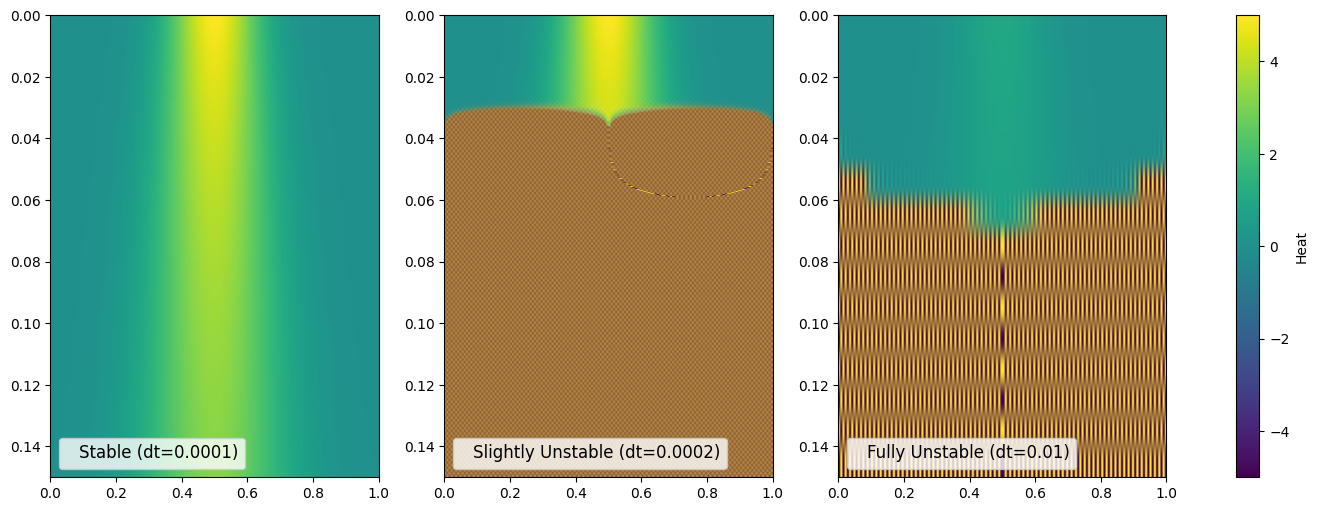

time: 5.55 s (started: 2026-04-15 01:39:35 +00:00)


In [ ]:
##QUestion 2 B:
alpha_b = 0.05
dt_b = 0.01
T_b = 0.15
Nt_b = int(T_b / dt_b)
N=150
wavenumbers = np.fft.fftfreq(N, d=1/N) * 2 * np.pi
#current_k = func1b3(func1(arraytest400))
heat_history = np.zeros((Nt_b, N))

def simulate_heat(dt_b):
    Nt_b = int(T_b / dt_b)
    current_k = func1b3(func1(arraytest150))
    #current_k = func1b3(func1(arraytest400)) #400 maybe takes a bit too long and is only filled in for the first 10% of the graph, 150 is better

    heat_history = np.zeros((Nt_b, N))

    for i in range(Nt_b):
        heat_history[i] = np.real(func1b4(current_k))
        current_k = current_k - dt_b * alpha_b * (wavenumbers**2) * current_k

    return heat_history

heat_stable = simulate_heat(0.0001)
heat_slight = simulate_heat(0.0002)
heat_unstable = simulate_heat(0.01)


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

c1 = ax1.imshow(heat_stable, aspect='auto', extent=[0, 1, T_b, 0], cmap='viridis', vmin=-1, vmax=1)
ax1.plot([], [], ' ', label="Stable (dt=0.0001)")
ax1.legend(loc="lower left", handlelength=0, fontsize=12)

c2 = ax2.imshow(heat_slight, aspect='auto', extent=[0, 1, T_b, 0], cmap='viridis', vmin=-1, vmax=1)
ax2.plot([], [], ' ', label="Slightly Unstable (dt=0.0002)")
ax2.legend(loc="lower left", handlelength=0, fontsize=12)

c3 = ax3.imshow(heat_unstable, aspect='auto', extent=[0, 1, T_b, 0], cmap='viridis', vmin=-5, vmax=5)
ax3.plot([], [], ' ', label="Fully Unstable (dt=0.01)")
ax3.legend(loc="lower left", handlelength=0, fontsize=12)


fig.colorbar(c3, ax=[ax1, ax2, ax3], label="Heat")

plt.show()